# GROUND TRUTH DATA ANALYSIS & VISUALIZATION (GROUND TRUTH EDA)
**Course:** Natural Language Processing (NLP)  
**Presenter:** [Student Name]  
**Objective:** Analyze the statistical characteristics and data structure of the 80-question benchmark dataset (`test_queries.jsonl`) annotated using the SOTA Retrieval-Assisted Annotation pipeline.

---
## 1. INDEPENDENT ANNOTATION METHODOLOGY (SOTA RETRIEVAL PIPELINE)

To completely eliminate **Circular Bias** when evaluating the RAG system, the Ground Truth dataset was annotated using a large-scale, academically rigorous independent search pipeline:

### 1.1 Semantic Denoising with the GTE-Qwen2-1.5B-instruct Model
A dense embedding model with **1.5 billion parameters** (compared to 100M-300M in standard RAG models).
* **Architecture:** A decoder-only transformer supporting Bidirectional Attention, optimized for learning semantic representations of long and complex queries.
* **Proven Performance:** Ranks at the top of the **MTEB (Massive Text Embedding Benchmark)** leaderboard for retrieval tasks.

### 1.2 Minimizing Data Loss with ColBERTv2 (Late Interaction)
Unlike standard bi-encoders that compress an entire passage into a single vector, ColBERTv2 retains token-level embeddings for every word and computes cross-similarity using the MaxSim operator:

$$\text{MaxSim}(Q, D) = \sum_{q \in Q} \max_{d \in D} (E_q \cdot E_d^T)$$

This mechanism preserves the features of isolated numerical data points inside the SEC 10-K financial reports, preventing semantic dilution.

### 1.3 Validation using an LLM-as-a-Judge Model
Simulating the methodology of the *"Judging LLM-as-a-judge"* research (LMSYS Org / UC Berkeley).
* The **Llama-3.3-70B-Instruct** model acts as the judge, reading the question and the candidate text passages retrieved by GTE-Qwen2 and ColBERTv2.
* The judge analyzes the financial reasoning, extracts the exact figures, and verifies which passage actually contains the answer to assign as the official Ground Truth label.

In [8]:
# 2. IMPORT LIBRARIES & VISUALIZATION CONFIGURATION
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120

In [9]:
# 3. LOAD & PREPROCESS JSONL DATA
data_path = Path("../../data/eval/test_queries.jsonl")
queries = []

with open(data_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            queries.append(json.loads(line))

# Convert to DataFrame for statistical analysis
df = pd.DataFrame(queries)

# Extract additional fields from metadata for analysis
df["Ticker"] = df["metadata"].apply(lambda x: x.get("ticker", "UNKNOWN"))
df["Year"] = df["metadata"].apply(lambda x: str(x.get("year", "UNKNOWN")))
df["GT_Count"] = df["ground_truth_chunks"].apply(len)
df["Query_Length"] = df["query"].apply(lambda x: len(x.split()))

print(f"Total queries in the benchmark dataset: {len(df)}")
print("=== FIRST DATA SAMPLE ===")
display(df.head(3))

Total queries in the benchmark dataset: 80
=== FIRST DATA SAMPLE ===


,query_id,query,category,ground_truth_chunks,ground_truth_explanation,metadata,Ticker,Year,GT_Count,Query_Length
0,sq_01,What was the consolidated operating income for...,factual,"[AMZN_2023_10K_Item7_c008, AMZN_2023_10K_Item8...",Chunks AMZN_2023_10K_Item7_c008 and AMZN_2023_...,"{'tickers': ['AMZN'], 'years': [2023], 'ticker...",AMZN,2023,2,10
1,sq_02,What was Amazons (AMZN) cost of sales in 2023?,factual,[AMZN_2023_10K_Item7_c009],This chunk contains the exact numerical figure...,"{'tickers': ['AMZN'], 'years': [2023], 'ticker...",AMZN,2023,1,9
2,sq_03,What were the total operating expenses of Amaz...,factual,[AMZN_2022_10K_Item7_c009],This chunk contains the exact numerical figure...,"{'tickers': ['AMZN'], 'years': [2022], 'ticker...",AMZN,2022,1,10


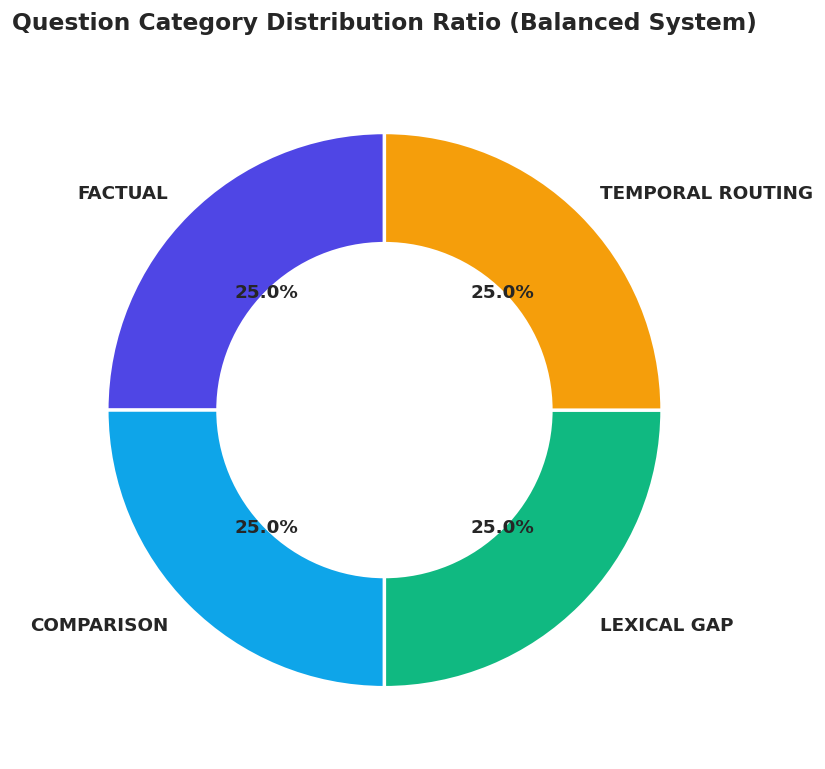

In [10]:
# 4. PLOT 1: QUESTION CATEGORY DISTRIBUTION (Pie Chart / Donut Chart)
category_counts = df["category"].value_counts()
colors = ["#4f46e5", "#0ea5e9", "#10b981", "#f59e0b"]

plt.figure(figsize=(7, 7))
plt.pie(category_counts, labels=[c.upper().replace("_", " ") for c in category_counts.index], 
        autopct='%1.1f%%', startangle=90, colors=colors, 
        wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2), 
        textprops={'fontsize': 11, 'weight': 'bold'})

plt.title("Question Category Distribution Ratio (Balanced System)", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("../../eval/figures/eda_category_distribution.png", dpi=150)
plt.show()

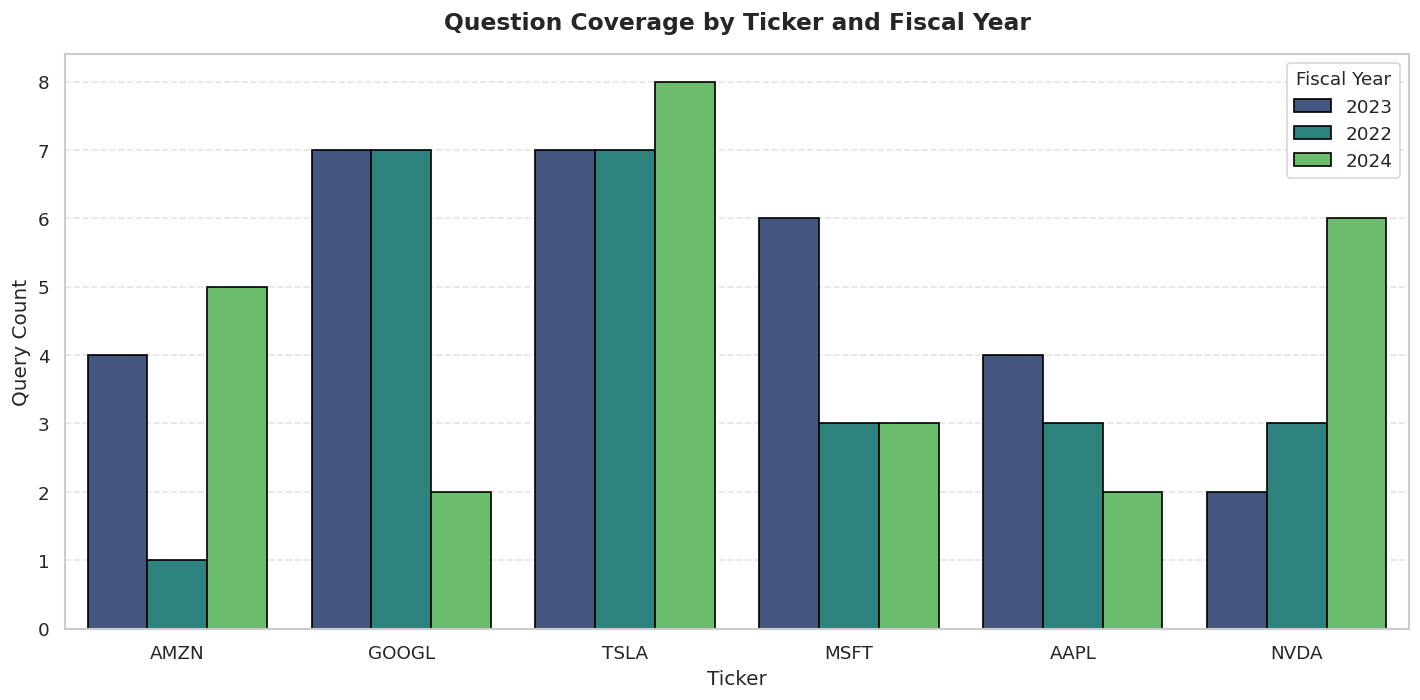

In [11]:
# 5. PLOT 2: COVERAGE BY COMPANY & FISCAL YEAR (Grouped Bar Chart)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="Ticker", hue="Year", palette="viridis", edgecolor="black")

plt.title("Question Coverage by Ticker and Fiscal Year", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Ticker", fontsize=12)
plt.ylabel("Query Count", fontsize=12)
plt.legend(title="Fiscal Year", fontsize=11, title_fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("../../eval/figures/eda_ticker_year_coverage.png", dpi=150)
plt.show()

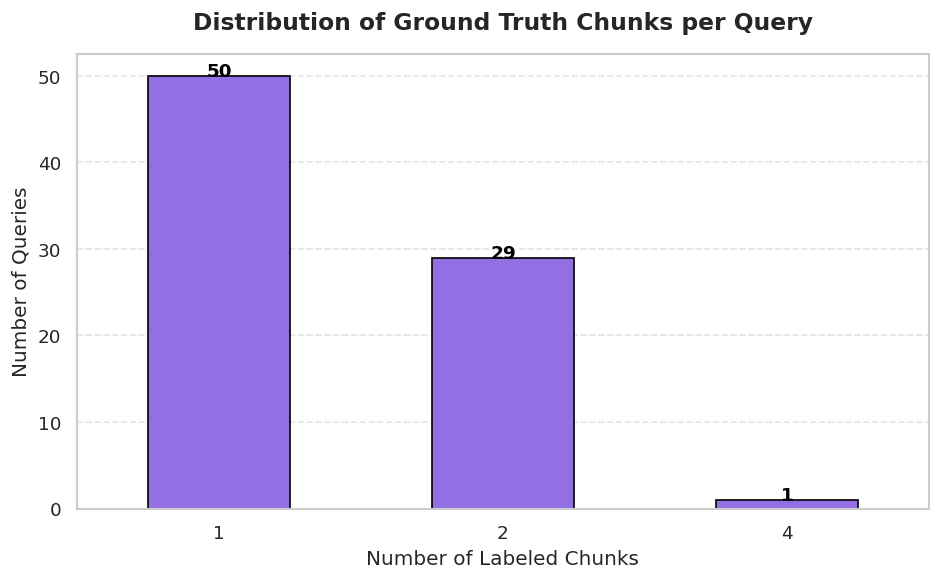

In [12]:
# 6. PLOT 3: STATISTICS OF GROUND TRUTH CHUNKS PER QUERY (Count Plot)
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="GT_Count", color="#8b5cf6", edgecolor="black", width=0.5)

plt.title("Distribution of Ground Truth Chunks per Query", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Number of Labeled Chunks", fontsize=12)
plt.ylabel("Number of Queries", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() + 0.5), 
                ha='center', va='center', fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig("../../eval/figures/eda_gt_chunks_distribution.png", dpi=150)
plt.show()

C:\Users\huynh\AppData\Local\Temp\ipykernel_24116\2967540098.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="category", y="Query_Length", palette="Set2", inner="quartile")


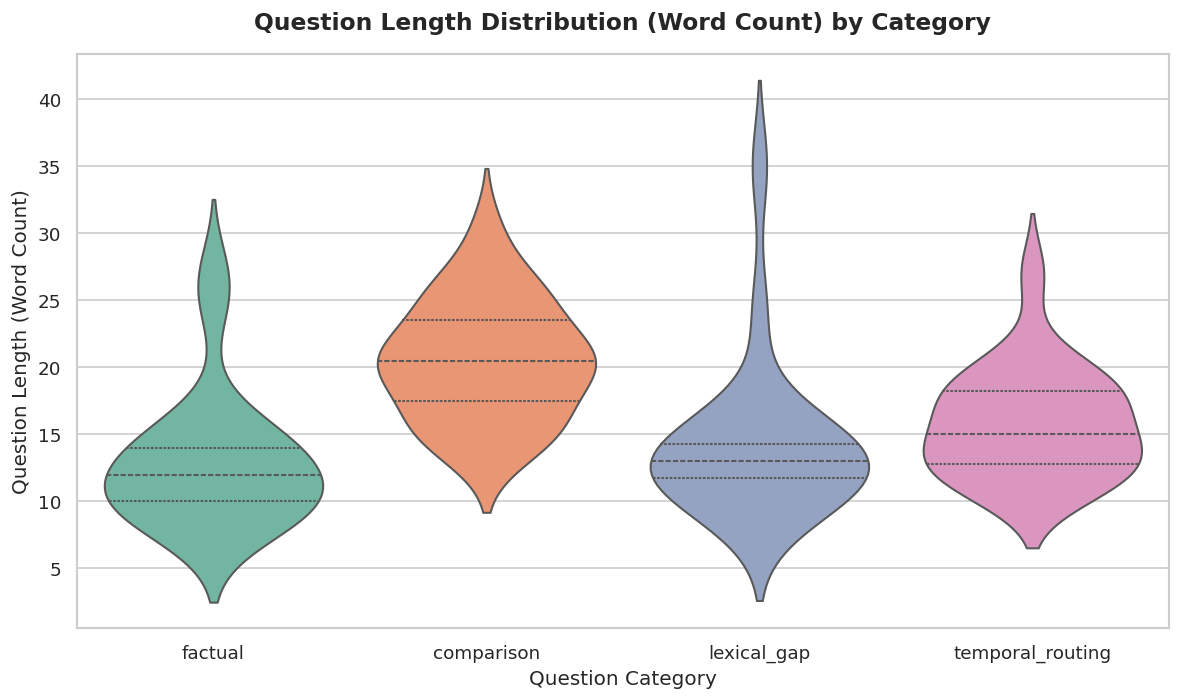

In [13]:
# 7. PLOT 4: QUESTION LENGTH BY CATEGORY (Violin Plot)
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="category", y="Query_Length", palette="Set2", inner="quartile")

plt.title("Question Length Distribution (Word Count) by Category", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Question Category", fontsize=12)
plt.ylabel("Question Length (Word Count)", fontsize=12)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.savefig("../../eval/figures/eda_query_length_distribution.png", dpi=150)
plt.show()

---
## 8. QUALITY ANALYSIS OF GROUND TRUTH EXPLANATIONS

A major enhancement in the new Ground Truth dataset is the inclusion of the `ground_truth_explanation` field from the Llama-3.3-70B judge, providing maximum transparency:

* **Preventing Data Leakage:** Ensures that the annotated passages actually contain the mathematical values or financial facts needed to infer the answer, rather than just matching surface-level keywords.
* **Supporting Audits:** When presenting the project, students can directly fetch the explanation and the actual numbers extracted from the original 10-K reports to defend their results.